In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set visualization style
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/My Drive/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

Mounted at /content/drive


In [3]:
df.shape

(7043, 21)

In [4]:
# Preview the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Quick statistical overview of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# List column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Drop 'customerID' as it doesn't contribute to churn prediction
df = df.drop('customerID', axis=1)

In [8]:
# Rename columns for readability
df = df.rename(columns={
    'gender': 'Gender',
    'SeniorCitizen': 'Senior_Citizen',
    'tenure': 'Tenure',
    'PhoneService': 'Phone_Service',
    'MultipleLines': 'Multiple_Lines',
    'InternetService': 'Internet_Service',
    'OnlineSecurity': 'Online_Security',
    'OnlineBackup': 'Online_Backup',
    'DeviceProtection': 'Device_Protection',
    'TechSupport': 'Tech_Support',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Movies',
    'PaperlessBilling': 'Paperless_Billing',
    'PaymentMethod': 'Payment_Method',
    'MonthlyCharges': 'Monthly_Charges',
    'TotalCharges': 'Total_Charges'
})

In [9]:
df.head()

,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Check for null values
df.isna().sum().sum()

np.int64(0)

In [11]:
df.columns

Index(['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

In [12]:
df.dtypes

,0
Gender,object
Senior_Citizen,int64
Partner,object
Dependents,object
Tenure,int64
Phone_Service,object
Multiple_Lines,object
Internet_Service,object
Online_Security,object
Online_Backup,object


In [13]:
# Clean 'Total_Charges' column: convert to numeric, coerce errors, drop NaNs

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

df = df.dropna(subset=['Total_Charges'])

df['Total_Charges'] = df['Total_Charges'].astype(float)

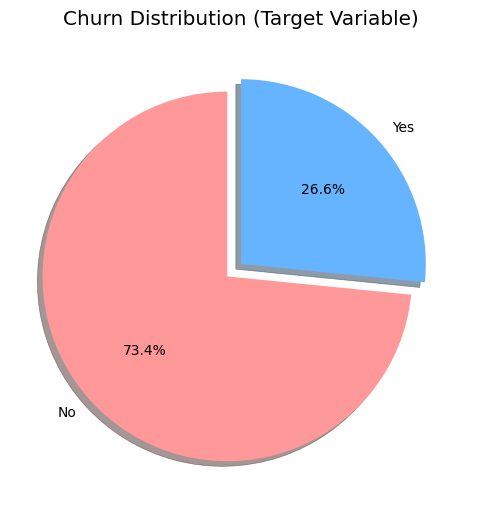

In [14]:
# 📊 Target Distribution (Churn vs No Churn)
plt.figure(figsize=(6, 6))
labels = df['Churn'].value_counts().index
sizes = df['Churn'].value_counts().values
colors = ['#ff9999','#66b3ff']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0), shadow=True)
plt.title('Churn Distribution (Target Variable)')
plt.show()

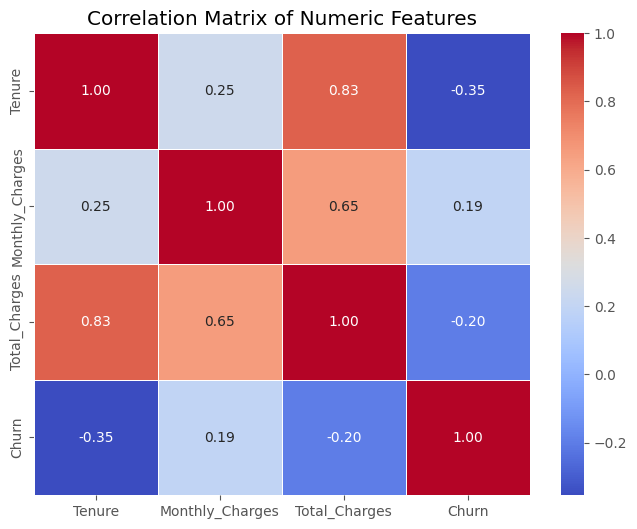

In [15]:
# 📊 Correlation Matrix
# Convert Churn to numeric temporarily for correlation
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select only numerical columns
corr_matrix = df_corr[['Tenure', 'Monthly_Charges', 'Total_Charges', 'Churn']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

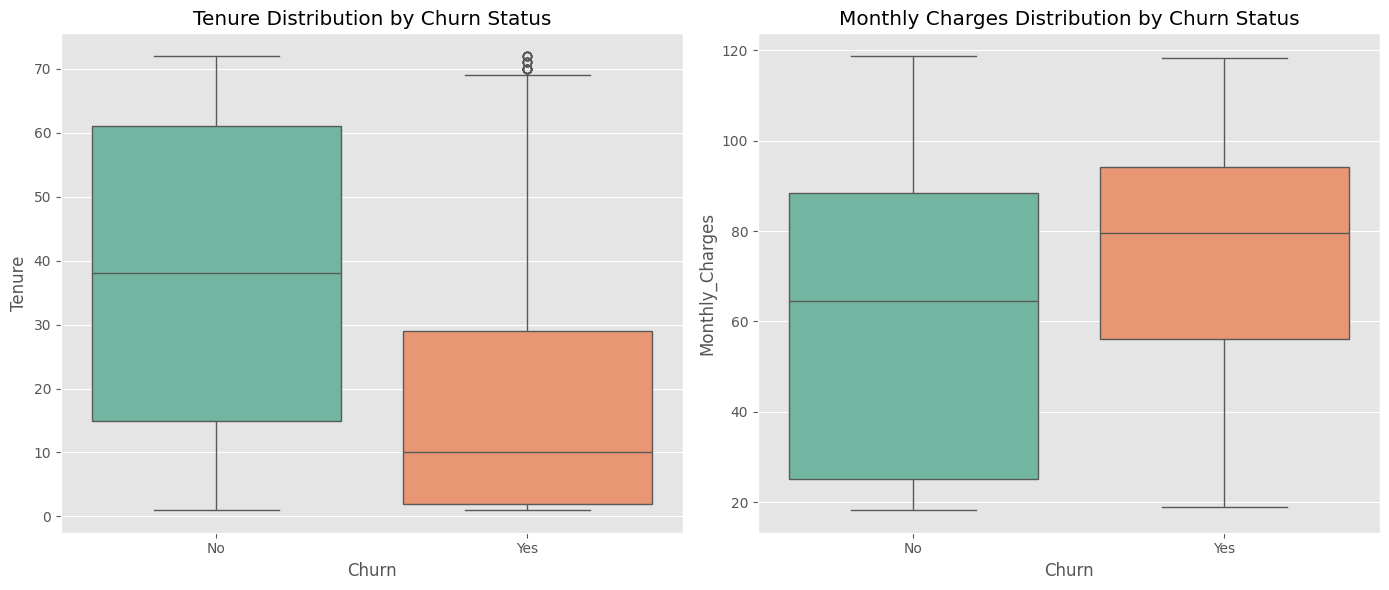

In [16]:
# 📊 Box Plots for Numerical Features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tenure vs Churn
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='Monthly_Charges', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status')

plt.tight_layout()
plt.show()

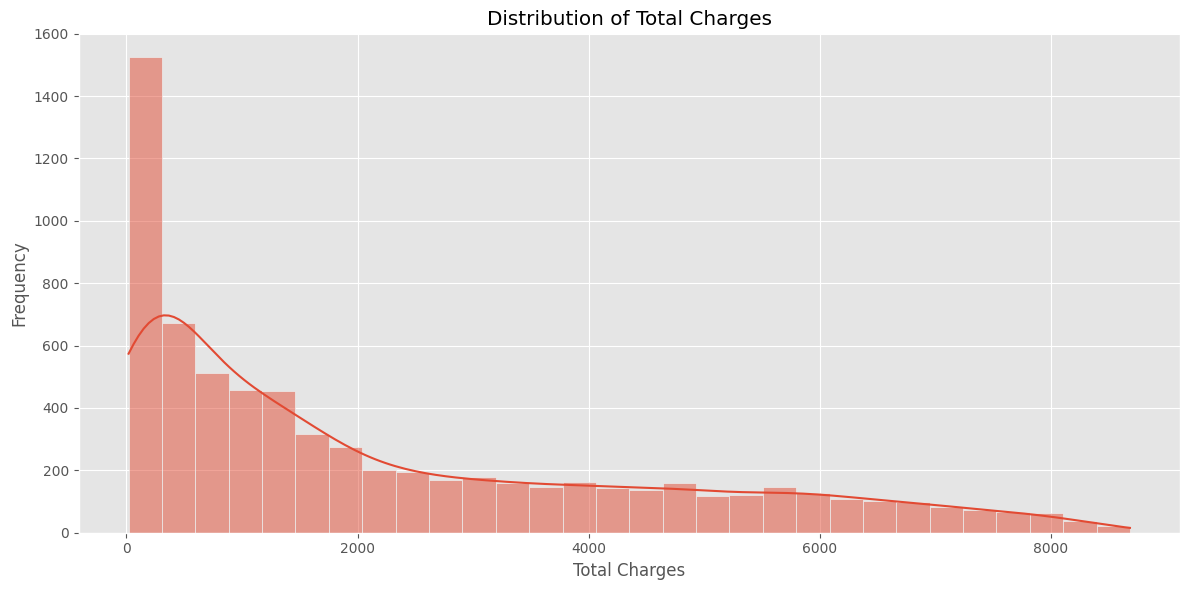

In [ ]:
# Plot distribution of total charges

plt.figure(figsize=(12, 6))
sns.histplot(df['Total_Charges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()

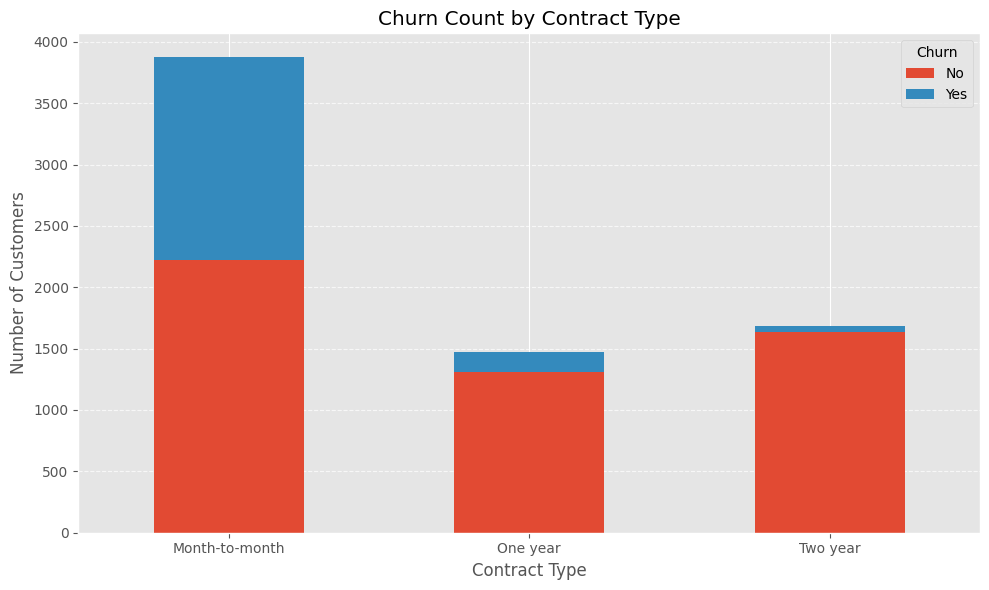

In [ ]:
# Analyze churn by contract type

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df_clean = df.dropna(subset=['Total_Charges'])

contract_churn = df_clean.groupby(['Contract', 'Churn']).size().unstack()

contract_churn.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Feature lists

num_features = ['Tenure', 'Monthly_Charges', 'Total_Charges']

cat_features = ['Gender','Senior_Citizen','Partner','Dependents','Phone_Service','Multiple_Lines',
                'Internet_Service','Online_Security','Online_Backup','Device_Protection','Tech_Support',
                'Streaming_TV', 'Streaming_Movies','Contract','Paperless_Billing','Payment_Method']

target = 'Churn'

In [ ]:
# Prepare features and labels
X = df[num_features + cat_features]
y = df[target].map({'Yes': 1, 'No': 0})

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [ ]:
# Build preprocessing pipeline (StandardScaler for numerical, OneHot for categorical)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [ ]:
# Model Definitions and Setup

# Dictionary of models to test. Note: class_weight='balanced' helps address class imbalance.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    # Gradient Boosting does not support class_weight directly, relying on its boosting technique
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVC (Prob)": SVC(probability=True, class_weight='balanced', random_state=42)
}

# Variables to store results and track the best model
results = []
best_model = None
best_auc = 0  # We will use ROC-AUC as the tie-breaker for "best" model

# Initialize the plot figure for ROC Curves
plt.figure(figsize=(10, 8))

print("Setup complete. Ready to begin testing...")

Setup complete. Ready to begin testing...


<Figure size 1000x800 with 0 Axes>

Running tests on models...

Testing Logistic Regression...
   Accuracy: 0.7332 | F1 Score: 0.6134 | ROC-AUC: 0.8400 | CV AUC (Mean): 0.8459
Testing Random Forest...
   Accuracy: 0.7816 | F1 Score: 0.5236 | ROC-AUC: 0.8128 | CV AUC (Mean): 0.8216
Testing Gradient Boosting...
   Accuracy: 0.7947 | F1 Score: 0.5697 | ROC-AUC: 0.8401 | CV AUC (Mean): 0.8456
Testing SVC (Prob)...
   Accuracy: 0.7292 | F1 Score: 0.6073 | ROC-AUC: 0.8143 | CV AUC (Mean): 0.8285

All models trained and evaluated. Moving to final comparison.


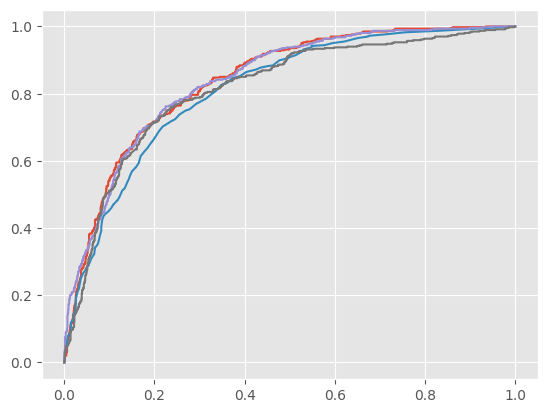

In [ ]:
# Training, Evaluation, and Cross-Validation Loop

print("Running tests on models...\n")

for name, model in models.items():
    # 1. Build pipeline (Preprocessor + Model)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # 2. Train and Fit
    pipeline.fit(X_train, y_train)

    # 3. Predict Probabilities (Needed for AUC)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # 4. Calculate Metrics (Accuracy, F1, and the robust ROC-AUC)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # 5. Perform Cross-Validation (The "Stability" Test)
    # Checks stability of performance across 5 different folds of the training data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()

    print(f"Testing {name}...")
    print(f"   Accuracy: {acc:.4f} | F1 Score: {f1:.4f} | ROC-AUC: {auc:.4f} | CV AUC (Mean): {cv_mean:.4f}")

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': auc,
        'CV AUC': cv_mean
    })

    # 6. Plot ROC Curve for the current model
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    # 7. Logic to track the absolute best model based on AUC
    if auc > best_auc:
        best_auc = auc
        best_model = pipeline
        best_model_name = name

print("\nAll models trained and evaluated. Moving to final comparison.")

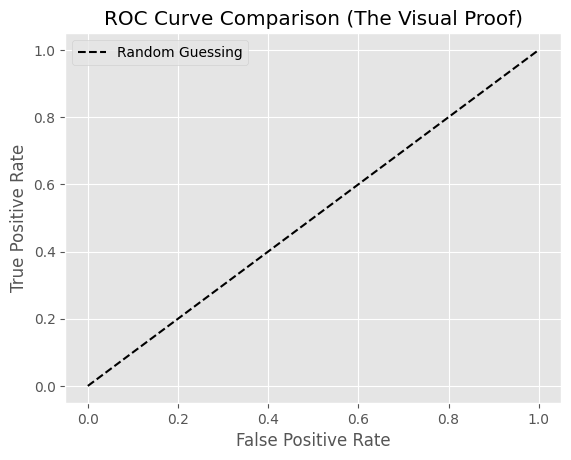


🏆 The Winner based on ROC-AUC is: Gradient Boosting

Model Leaderboard:
                 Model  Accuracy  F1 Score   ROC-AUC    CV AUC
2    Gradient Boosting  0.794653  0.569726  0.840059  0.845613
0  Logistic Regression  0.733220  0.613355  0.840032  0.845898
3           SVC (Prob)  0.729238  0.607261  0.814311  0.828475
1        Random Forest  0.781570  0.523573  0.812785  0.821551


In [ ]:
# Final ROC Curve Plot and Winner Determination

# Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (The Visual Proof)')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n🏆 The Winner based on ROC-AUC is: {best_model_name}")

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("\nModel Leaderboard:")
print(results_df)


In [ ]:
# Save the best model using joblib
model_filename = 'best_churn_model.pkl'
joblib.dump(best_model, model_filename)

print(f"✅ The {best_model_name} model has been saved as '{model_filename}'")
print("You can load this in your GUI application using: model = joblib.load('best_churn_model.pkl')")

✅ The Gradient Boosting model has been saved as 'best_churn_model.pkl'
You can load this in your GUI application using: model = joblib.load('best_churn_model.pkl')
